In [1]:
from google.colab import files
uploaded = files.upload()

Saving mao_b_ic50.csv to mao_b_ic50.csv
Saving AChE_Bioactivity_data_2.csv to AChE_Bioactivity_data_2.csv


In [2]:
!pip install pandas matplotlib seaborn rdkit scikit-learn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 22.3 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


maob_df = pd.read_csv("mao_b_ic50.csv")
ache_df = pd.read_csv("AChE_Bioactivity_data_2.csv")


maob_df = maob_df.rename(columns={'smiles': 'canonical_smiles', 'ic50': 'standard_value'})
maob_df['standard_value'] *= 1000
df = pd.concat([maob_df, ache_df], ignore_index=True)


df = df.dropna(subset=['canonical_smiles', 'standard_value'])
df = df[(df['standard_value'] > 0) & (df['standard_value'] < 1_000_000)]


df['log_ic50'] = np.log10(df['standard_value'])

from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

generator = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_ecfp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = generator.GetFingerprint(mol)
        arr = np.zeros((fp.GetNumBits(),), dtype=int)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    else:
        return np.zeros((2048,))


X = np.array(df['canonical_smiles'].apply(smiles_to_ecfp).tolist())
y = df['log_ic50'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Sequential([
    Dense(512, input_shape=(X.shape[1],), activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_pred = model.predict(X_test).flatten()
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2}")
print(f"RMSE: {rmse}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 3.0386 - val_loss: 1.8806
Epoch 2/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 1.7013 - val_loss: 1.7205
Epoch 3/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 1.5652 - val_loss: 1.6996
Epoch 4/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 1.4422 - val_loss: 1.7284
Epoch 5/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 1.3635 - val_loss: 1.7072
Epoch 6/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 1.3649 - val_loss: 1.6734
Epoch 7/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 1.3434 - val_loss: 1.6216
Epoch 8/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1.2546 - val_loss: 1.6489
Epoch 9/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 1.2414 - val_loss: 1.6406
Epoch 10/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 1.2390 - val_loss: 1.6992
Epoch 11/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 1.2564 - val_loss: 1.6920
Epoch 12/100
261/261 ━━━━━━━━

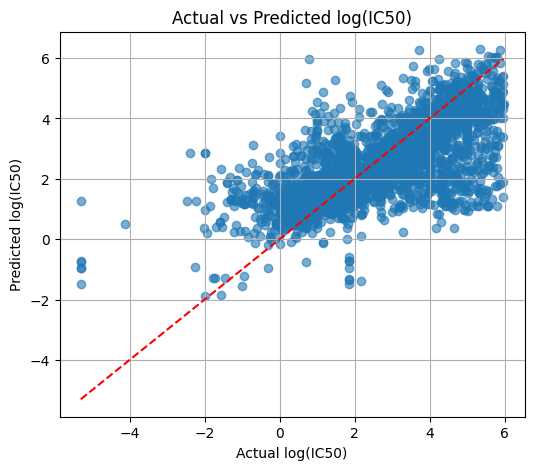

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('Actual log(IC50)')
plt.ylabel('Predicted log(IC50)')
plt.title('Actual vs Predicted log(IC50)')
plt.grid(True)
plt.show()